In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import funcoes
import plotly.graph_objects as go
pd.options.display.float_format = '{:.2f}'.format #para os números aparecerem com duas casas decimais
pd.set_option('display.max_columns', 50) #mostra 50 colunas ou o número desejado
pd.set_option('future.no_silent_downcasting', True)

dados = pd.read_excel("df_exp.xlsx")
dados.shape
seg = dados.copy()

In [2]:
funcoes.resumo(dados)

--- Formato ---
(471, 11)

--- Tipos de Dados ---
protocolo         float64
data               object
nome               object
sexo               object
faixa_etaria       object
cor                object
bairro             object
tipo_violencia     object
vínculo            object
obs                object
devolutiva        float64
dtype: object

--- Valores Nulos ---
protocolo           5
data                0
nome                0
sexo                0
faixa_etaria        0
cor                 0
bairro              8
tipo_violencia      0
vínculo             8
obs               463
devolutiva        471
dtype: int64

--- Resumo Estatístico ---


,protocolo,devolutiva
count,466.00,0.00
mean,3617573.21,NaN
std,239222.71,NaN
min,3286569.00,NaN
25%,3445627.00,NaN
50%,3610526.00,NaN
75%,3723809.50,NaN
max,4190066.00,NaN


In [3]:
funcoes.verificar_categorias(dados)

{'data': array([datetime.datetime(2025, 1, 2, 0, 0),
        datetime.datetime(2025, 1, 3, 0, 0),
        datetime.datetime(2025, 1, 7, 0, 0),
        datetime.datetime(2025, 1, 8, 0, 0),
        datetime.datetime(2025, 1, 9, 0, 0),
        datetime.datetime(2025, 1, 10, 0, 0),
        datetime.datetime(2025, 1, 13, 0, 0),
        datetime.datetime(2025, 1, 14, 0, 0),
        datetime.datetime(2025, 1, 23, 0, 0),
        datetime.datetime(2025, 1, 27, 0, 0),
        datetime.datetime(2025, 1, 29, 0, 0),
        datetime.datetime(2025, 1, 19, 0, 0),
        datetime.datetime(2025, 1, 30, 0, 0),
        datetime.datetime(2025, 1, 31, 0, 0),
        datetime.datetime(2025, 2, 5, 0, 0),
        datetime.datetime(2025, 2, 6, 0, 0),
        datetime.datetime(2025, 2, 8, 0, 0),
        datetime.datetime(2025, 3, 2, 0, 0),
        datetime.datetime(2025, 3, 5, 0, 0),
        datetime.datetime(2025, 3, 7, 0, 0),
        datetime.datetime(2025, 3, 10, 0, 0),
        datetime.datetime(2025, 3, 14

In [12]:
#seg.head()
seg['tipo_violencia'].unique()


array(['Física', 'Psicológica', 'Psíquica', 'Patrimonial', 'Negligência',
       'Abandono', 'Maus Tratos', 'Moral', 'Cárcere Privado',
       'Discriminação', 'Intolerância', 'Direitos Civis', 'Políticos'],
      dtype=object)

In [13]:
seg['tipo_violencia'].replace({
   ' Psicológica': 'Psicológica',
    'Psíquica': 'Psicológica',
    ' Patrimonial': 'Patrimonial',
    ' Negligência': 'Negligência',
    ' Abandono': 'Abandono',
    ' Maus Tratos': 'Maus Tratos',
    ' Moral': 'Moral',
    ' Cárcere Privado':'Cárcere Privado',
    ' Discriminação': 'Discriminação',
    ' Intolerância': 'Intolerância',
    ' Direitos Civis': 'Direitos Civis',
    ' Políticos': 'Políticos'
 
}, inplace=True)

C:\Users\lucaspassoni\AppData\Local\Temp\ipykernel_6044\147792694.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  seg['tipo_violencia'].replace({


In [14]:
#agregando o DF_EXPANDIDO por gênero e tipos de violência
df_genero = seg.groupby('tipo_violencia')['sexo'].value_counts().sort_values(ascending=False).reset_index(name='Total')
df_genero

,tipo_violencia,sexo,Total
0,Psicológica,Fem,122
1,Abandono,Fem,55
2,Negligência,Fem,55
3,Psicológica,Masc,42
4,Maus Tratos,Fem,40
5,Física,Fem,34
6,Abandono,Masc,22
7,Negligência,Masc,22
8,Patrimonial,Fem,21
9,Maus Tratos,Masc,18


In [31]:
df_pivot = df_genero.pivot_table(
    index = 'sexo',
    columns='tipo_violencia',
    values='Total',
    aggfunc='sum',
    fill_value=0 
)
#criando uma coluna total, somando as oorrencias por bairro
df_pivot['Total'] = df_pivot.sum(axis=1)
df_pivot

tipo_violencia,Abandono,Cárcere Privado,Direitos Civis,Discriminação,Física,Intolerância,Maus Tratos,Moral,Negligência,Patrimonial,Políticos,Psicológica,Total
sexo,,,,,,,,,,,,,
Fem,55,2,3,0,34,0,40,3,55,21,3,122,338
Masc,22,0,0,1,9,1,18,3,22,4,0,42,122
Não informado,2,0,0,0,1,0,1,0,2,1,0,4,11


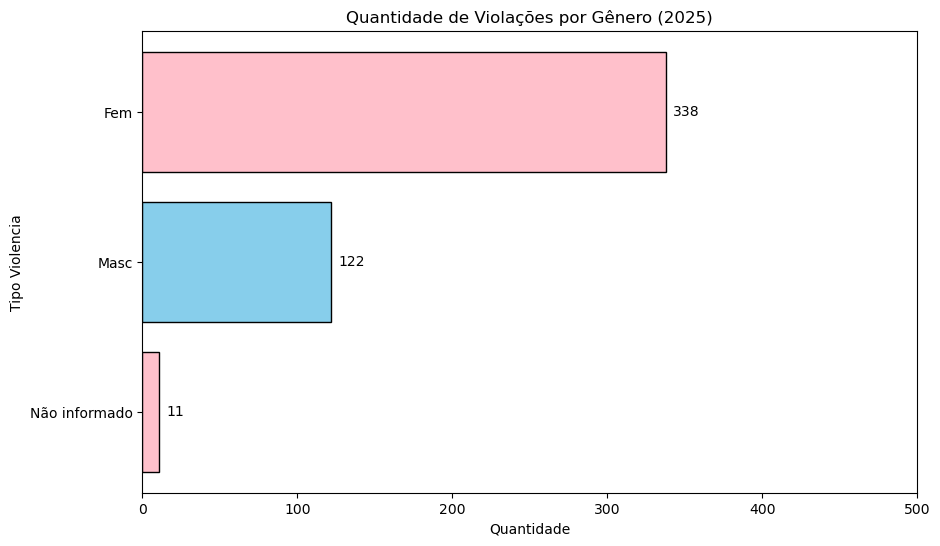

In [30]:
df_plot_violacoes_genero = df_pivot['Total']


contagem = df_pivot['Total'].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(contagem.index, contagem, color=["#FFC0CB", "#87CEEB"], edgecolor = 'black')
ax.set_title('Quantidade de Violações por Gênero (2025)')
ax.set_xlabel('Quantidade')
ax.set_ylabel('Tipo Violencia')
ax.set_xlim(0, 500)
ax.bar_label(ax.containers[0], padding = 5)

plt.savefig('Violacoes-genero-2025.png', dpi=300, bbox_inches='tight')

In [19]:
df_pivot_2

NameError: name 'df_pivot_2' is not defined

In [22]:
#fazendo a tabela pivot com as colunas como masculino e feminino
df_pivot_2 = df_genero.pivot_table(
    index = 'tipo_violencia',
    columns='sexo',
    values='Total',
    aggfunc='sum',
    fill_value=0 
)
#criando uma coluna total, somando as oorrencias por bairro
df_pivot_2['Total'] = df_pivot_2.sum(axis=1)
df_pivot_2 = df_pivot_2.sort_values(ascending=True, by='Total')
df_pivot_2 = df_pivot_2.drop(columns=['Total'])
df_pivot_2['Masc'] = df_pivot_2['Masc'] * -1
df_pivot_2

sexo,Fem,Masc,Não informado
tipo_violencia,,,
Discriminação,0,-1,0
Intolerância,0,-1,0
Cárcere Privado,2,0,0
Direitos Civis,3,0,0
Políticos,3,0,0
Moral,3,-3,0
Patrimonial,21,-4,1
Física,34,-9,1
Maus Tratos,40,-18,1


[]

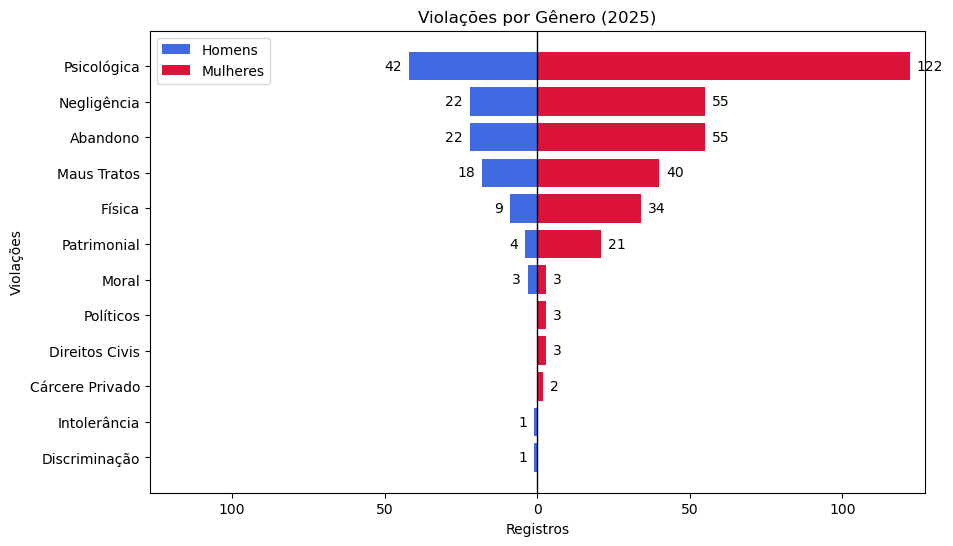

In [29]:
# 2. Configuração do gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Plotagem das barras
ax.barh(df_pivot_2.index, df_pivot_2['Masc'], color='royalblue', label='Homens')
ax.barh(df_pivot_2.index, df_pivot_2['Fem'], color='crimson', label='Mulheres')


#Legendas, eixos e numerações das barras
ax.set_title('Violações por Gênero (2025)')
ax.set_xlabel('Registros')
ax.set_ylabel('Violações')
ax.legend()
#formatando os rótulos e usando a função lambda para aplicar nas barras do lado negativo tbm


#o primeiro laço é pra iterar sobre as barras
#o segundo é pra definir os rótulos como strings se forem iguais a zero, e formatar como absoluto, para valor de cada barra
for container in ax.containers:
    labels = ["" if v == 0 else f'{abs(v):.0f}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5)

#ajuste na escala do eixo x
limite_maximo = max(max(df_pivot_2['Fem']), abs(min(df_pivot_2['Masc']))) + 5
ax.set_xlim(-limite_maximo, limite_maximo)


#formatando os rótulos do eixo x
ax.xaxis.set_major_formatter(lambda x, pos: f'{abs(int(x))}')


# Linha central de separação
ax.axvline(0, color='black', linewidth=1)

plt.savefig('Violacoes-genero-2025.png', dpi=300, bbox_inches='tight')

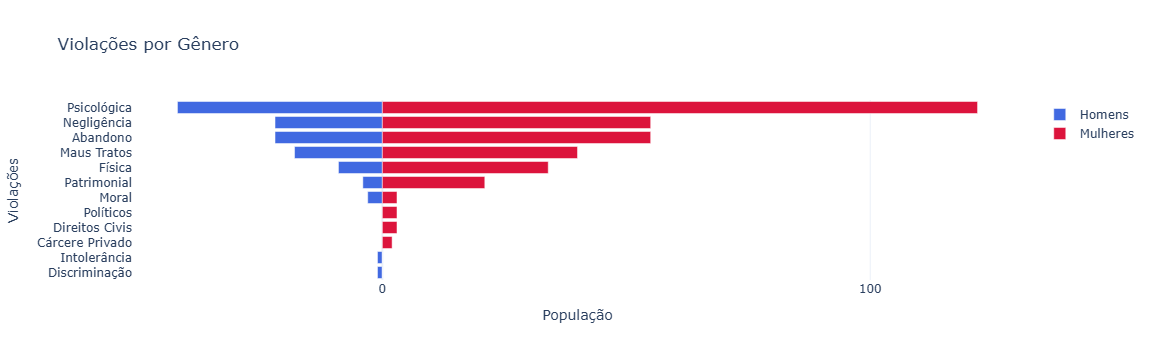

In [26]:
#fazendo o gráfico com plotly (não por ser interativo, mas por que parece boa opção pra montar o gráfico de pirâmide)
fig = go.Figure()

# Barra dos Homens (Esquerda)
fig.add_trace(go.Bar(
    x=df_pivot_2['Masc'],
    y=df_pivot_2.index,
    orientation='h',
    name='Homens',
    marker_color='royalblue'
))

# Barra das Mulheres (Direita)
fig.add_trace(go.Bar(
    x=df_pivot_2['Fem'],
    y=df_pivot_2.index,
    orientation='h',
    name='Mulheres',
    marker_color='crimson'
))

# 3. Ajustes do Layout (centralizando e formatando o eixo X)
fig.update_layout(
    barmode='overlay',
    title='Violações por Gênero',
    xaxis_title='População',
    yaxis_title='Violações',
    template='plotly_white'
)

# Ajuste para garantir que os números negativos apareçam como positivos nos eixos
fig.update_xaxes(
    tickformat = ',.0f', 
    tickvals = [-300, -200, -100, 0, 100, 200, 300],
    ticktext = ['300', '200', '100', '0', '100', '200', '300']
)